In [4]:
# Import and Load Data
import pandas as pd
import numpy as np

contract = pd.read_csv('/datasets/final_provider/contract.csv')
personal = pd.read_csv('/datasets/final_provider/personal.csv')
internet = pd.read_csv('/datasets/final_provider/internet.csv')
phone = pd.read_csv('/datasets/final_provider/phone.csv')

In [5]:
# Data preview
display(contract.head())
display(personal.head())
display(internet.head())
display(phone.head())

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65


,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


,customerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


In [6]:
# Data Shape
print('contract shape:', contract.shape)
print('personal shape:', personal.shape)
print('internet shape:', internet.shape)
print('phone shape:', phone.shape)

contract shape: (7043, 8)
personal shape: (7043, 5)
internet shape: (5517, 8)
phone shape: (6361, 2)


In [7]:
# Coulumns and info
print('CONTRACT')
contract.info()
print()

print('PERSONAL')
personal.info()
print()

print('INTERNET')
internet.info()
print()

print('PHONE')
phone.info()

CONTRACT
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
dtypes: float64(1), object(7)
memory usage: 440.3+ KB

PERSONAL
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   int64 
 3   Partner        7043 non-n

In [10]:
# Missing and Dupes
print('Missing values in contract:')
print(contract.isna().sum())
print()

print('Missing values in personal:')
print(personal.isna().sum())
print()

print('Missing values in internet:')
print(internet.isna().sum())
print()

print('Missing values in phone:')
print(phone.isna().sum())

print('Duplicate customerID in contract:', contract['customerID'].duplicated().sum())
print('Duplicate customerID in personal:', personal['customerID'].duplicated().sum())
print('Duplicate customerID in internet:', internet['customerID'].duplicated().sum())
print('Duplicate customerID in phone:', phone['customerID'].duplicated().sum())

Missing values in contract:
customerID          0
BeginDate           0
EndDate             0
Type                0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64

Missing values in personal:
customerID       0
gender           0
SeniorCitizen    0
Partner          0
Dependents       0
dtype: int64

Missing values in internet:
customerID          0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
dtype: int64

Missing values in phone:
customerID       0
MultipleLines    0
dtype: int64
Duplicate customerID in contract: 0
Duplicate customerID in personal: 0
Duplicate customerID in internet: 0
Duplicate customerID in phone: 0


In [11]:
# Target inspection
contract['EndDate'].value_counts()

No                     5174
2019-11-01 00:00:00     485
2019-12-01 00:00:00     466
2020-01-01 00:00:00     460
2019-10-01 00:00:00     458
Name: EndDate, dtype: int64

In [14]:
print(contract['TotalCharges'].value_counts().head(10))
print(contract['TotalCharges'].replace(" ", np.nan).isna().sum())

20.2     11
         11
19.75     9
19.65     8
20.05     8
19.9      8
45.3      7
19.55     7
19.45     6
20.25     6
Name: TotalCharges, dtype: int64
11


## Work Plan

#### Data Preparation
1. Merge the contract, personal, internet, and phone datasets using customerID. Convert columns to appropriate data types, handle missing values, and create the churn target variable.

#### Exploratory Data Analysis (EDA)
2. Examine churn distribution and analyze relationships between customer attributes, service usage, and churn.

#### Feature Processing
3. Encode categorical variables and engineer useful features such as customer tenure.

#### Model Development and Evaluation
4. Train multiple classification models and evaluate performance using ROC-AUC and accuracy.

#### Final Model Selection
5. Select the best model based on ROC-AUC and summarize key factors influencing churn.

In [15]:
contract.head()

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65


## Data Preparation

In [16]:
# Merge Datasets
df = contract.merge(personal, on='customerID', how='left') \
             .merge(internet, on='customerID', how='left') \
             .merge(phone, on='customerID', how='left')

df.shape

(7043, 20)

In [18]:
# Creating Churn Target
df['churn'] = (df['EndDate'] != 'No').astype(int)

df['churn'].value_counts()

0    5174
1    1869
Name: churn, dtype: int64

In [22]:
# Fill missing values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)
print(df['TotalCharges'].isna().sum())

0


In [23]:
# Tenure feature
df['BeginDate'] = pd.to_datetime(df['BeginDate'])

df['EndDate'] = df['EndDate'].replace('No', '2020-02-01')
df['EndDate'] = pd.to_datetime(df['EndDate'])

df['tenure_days'] = (df['EndDate'] - df['BeginDate']).dt.days

df[['BeginDate','EndDate','tenure_days']].head()

,BeginDate,EndDate,tenure_days
0,2020-01-01,2020-02-01,31
1,2017-04-01,2020-02-01,1036
2,2019-10-01,2019-12-01,61
3,2016-05-01,2020-02-01,1371
4,2019-09-01,2019-11-01,61


In [28]:
print(df.describe())
print(df['tenure_days'].describe())

       MonthlyCharges  TotalCharges  SeniorCitizen        churn  tenure_days
count     7043.000000   7043.000000    7043.000000  7043.000000  7043.000000
mean        64.761692   2279.734304       0.162147     0.265370   985.996166
std         30.090047   2266.794470       0.368612     0.441561   747.587844
min         18.250000      0.000000       0.000000     0.000000     0.000000
25%         35.500000    398.550000       0.000000     0.000000   273.000000
50%         70.350000   1394.550000       0.000000     0.000000   883.000000
75%         89.850000   3786.600000       0.000000     1.000000  1676.000000
max        118.750000   8684.800000       1.000000     1.000000  2191.000000
count    7043.000000
mean      985.996166
std       747.587844
min         0.000000
25%       273.000000
50%       883.000000
75%      1676.000000
max      2191.000000
Name: tenure_days, dtype: float64


## Exploratory Data Analysis

In [32]:
# Churn distribution
df['churn'].value_counts(normalize=True)

0    0.73463
1    0.26537
Name: churn, dtype: float64

In [31]:
# Contract Type vs Churn
pd.crosstab(df['Type'], df['churn'], normalize='index')

churn,0,1
Type,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


In [34]:
# Tenure vs Churn
df.groupby('churn')['tenure_days'].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,5174.0,1144.447236,733.897937,0.0,457.0,1157.0,1857.0,2191.0
1,1869.0,547.352060,594.389607,30.0,61.0,304.0,883.0,2191.0


In [35]:
# Monthly Charges vs Churn
df.groupby('churn')['MonthlyCharges'].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
1,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


In [36]:
# Internet Service vs Churn
pd.crosstab(df['InternetService'], df['churn'], normalize='index')

churn,0,1
InternetService,,
DSL,0.810409,0.189591
Fiber optic,0.581072,0.418928


## EDA Key Findings
#### Churn Distribution
Approximately 26.5% of customers have churned, indicating a moderately imbalanced classification problem.

#### Contract Type
Customers with month-to-month contracts have the highest churn rate; ~43%, while customers with one-year; ~11% and two-year contracts; ~3% churn significantly less. Contract duration appears to be one of the strongest indicators of churn risk.

#### Customer Tenure
Churned customers have much shorter tenure (average ≈ 547 days) compared to retained customers (average ≈ 1144 days). This suggests newer customers are far more likely to leave the service.

#### Monthly Charges
Customers who churn tend to pay higher monthly charges on average approximately 74 USD vs 61 USD, suggesting that pricing or perceived value may influence customer retention.
#### Internet Service
Customers using fiber optic internet show a significantly higher churn rate; ~42% compared to DSL users; ~19%. This may indicate higher expectations or dissatisfaction within this segment.

## Preparing Data for Machine Learning

In [40]:
# Dropping columns and ancoding categorical variables
df_model = df.drop(['customerID','BeginDate','EndDate'], axis=1)
df_model = pd.get_dummies(df_model, drop_first=True)

In [42]:
# Split Features and Target
X = df_model.drop('churn', axis=1)
y = df_model['churn']

In [44]:
# Train / Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(X_train.shape)
print(X_test.shape)

(5634, 21)
(1409, 21)


## Model Training and Evaluation

In [45]:
# Baseline Logistic Regression 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:,1]

log_auc = roc_auc_score(y_test, y_prob)
log_acc = accuracy_score(y_test, y_pred)

print("Logistic Regression ROC-AUC:", log_auc)
print("Logistic Regression Accuracy:", log_acc)

Logistic Regression ROC-AUC: 0.8353587021106202
Logistic Regression Accuracy: 0.7998580553584103


In [47]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train, y_train)

y_pred = tree_model.predict(X_test)
y_prob = tree_model.predict_proba(X_test)[:,1]

tree_auc = roc_auc_score(y_test, y_prob)
tree_acc = accuracy_score(y_test, y_pred)

print("Decision Tree ROC-AUC:", tree_auc)
print("Decision Tree Accuracy:", tree_acc)

Decision Tree ROC-AUC: 0.6935415536438554
Decision Tree Accuracy: 0.7608232789212207


#### Baseline Models
Logistic Regression provides a strong baseline and demonstrates good predictive performance using a simple linear model. The Decision Tree model performs worse than Logistic Regression, likely due to overfitting and instability in single-tree structures. More advanced ensemble models will be explored to improve predictive performance.

In [48]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:,1]

rf_auc = roc_auc_score(y_test, y_prob)
rf_acc = accuracy_score(y_test, y_pred)

print("Random Forest ROC-AUC:", rf_auc)
print("Random Forest Accuracy:", rf_acc)

Random Forest ROC-AUC: 0.8601333023327907
Random Forest Accuracy: 0.8140525195173882


In [49]:
# Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred = gb_model.predict(X_test)
y_prob = gb_model.predict_proba(X_test)[:,1]

gb_auc = roc_auc_score(y_test, y_prob)
gb_acc = accuracy_score(y_test, y_pred)

print("Gradient Boosting ROC-AUC:", gb_auc)
print("Gradient Boosting Accuracy:", gb_acc)

Gradient Boosting ROC-AUC: 0.8843705598181302
Gradient Boosting Accuracy: 0.8325053229240597


In [51]:
# Model Comparision 
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "ROC-AUC": [
        log_auc,
        tree_auc,
        rf_auc,
        gb_auc
    ],
    "Accuracy": [
        log_acc,
        tree_acc,
        rf_acc,
        gb_acc
    ]
})

model_results.sort_values(by="ROC-AUC", ascending=False)

,Model,ROC-AUC,Accuracy
3,Gradient Boosting,0.884371,0.832505
2,Random Forest,0.860133,0.814053
0,Logistic Regression,0.835359,0.799858
1,Decision Tree,0.693542,0.760823


## Model Comparison

Gradient Boosting achieved the highest performance among the tested models with a ROC-AUC of 0.884 and an accuracy of 0.833.

Logistic Regression also performed well with a ROC-AUC of 0.835, indicating that several linear relationships exist within the dataset.

Random Forest improved upon the baseline models with a ROC-AUC of 0.860, while the single Decision Tree performed significantly worse due to overfitting and instability.

Based on the ROC-AUC metric, Gradient Boosting was selected as the final model.

In [53]:
# Top Churn Risk Customers
final_probs = gb_model.predict_proba(X_test)[:, 1]

results = X_test.copy()
results['actual_churn'] = y_test.values
results['churn_probability'] = final_probs

results[['churn_probability', 'actual_churn']].sort_values(
    by='churn_probability', ascending=False
).head(10)

,churn_probability,actual_churn
6509,0.987773,1
1334,0.986435,1
4585,0.976277,1
6623,0.975221,1
2464,0.974503,1
2526,0.974416,1
1458,0.974320,1
6866,0.973958,1
2753,0.973614,1
4065,0.971900,1


## Practical Use of the Model

The final model produces churn probabilities for each customer. In practice, Interconnect could use these probabilities to segment customers by risk level and assign retention actions accordingly.

For example:
- High-risk customers could receive immediate promotional offers or personalized outreach
- Medium-risk customers could receive lighter retention campaigns
- Low-risk customers may not require intervention

This would allow the company to focus retention resources where they are most likely to have an impact.

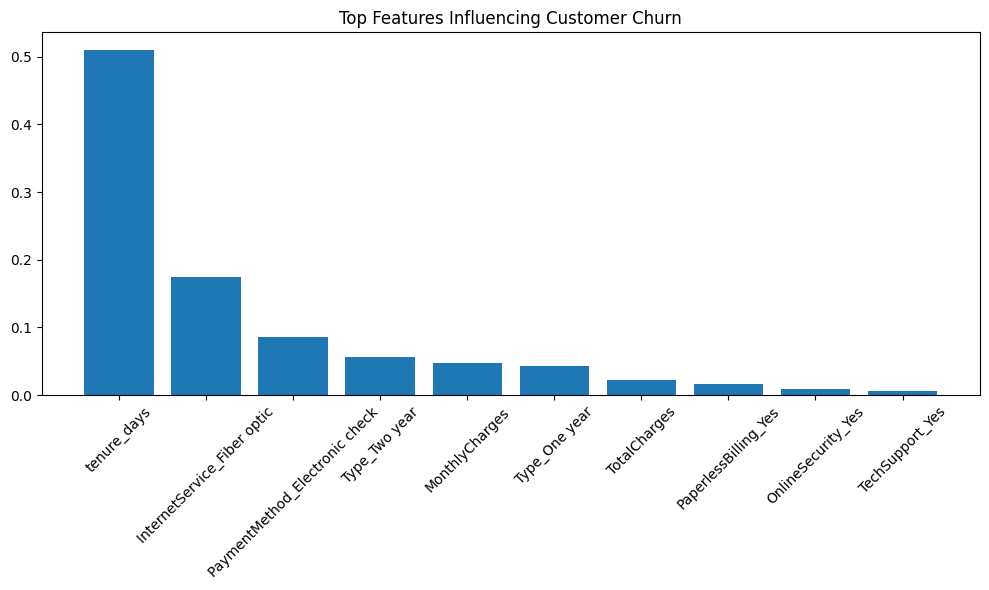

In [52]:
# Feature Analyzation
import matplotlib.pyplot as plt
import numpy as np

importances = gb_model.feature_importances_
indices = np.argsort(importances)[::-1]

feature_names = X.columns

top_n = 10

plt.figure(figsize=(10,6))
plt.title("Top Features Influencing Customer Churn")

plt.bar(range(top_n),
        importances[indices][:top_n],
        align="center")

plt.xticks(range(top_n),
           feature_names[indices][:top_n],
           rotation=45)

plt.tight_layout()
plt.show()

### Feature Analysis Findings

Customer tenure (tenure_days) was by far the most influential feature in predicting churn. Customers with shorter tenure are significantly more likely to leave the service, indicating that the first months of a customer's lifecycle are the most critical for retention.

The type of internet service also plays an important role. Customers using fiber optic internet show higher churn rates compared to DSL users, which may reflect higher expectations or dissatisfaction within this segment.

Payment method was another important factor. Customers paying via electronic check appear more likely to churn than customers using automatic payment methods.

Monthly charges also contribute to churn prediction, with customers paying higher monthly fees showing a higher likelihood of leaving the service.

Overall, the model suggests that contract structure, tenure, pricing, and service type are the key drivers of customer churn.

# Business Conclusions

Interconnect requested a machine learning solution capable of predicting customer churn so that at-risk customers can be targeted with retention offers.

After merging and preprocessing the datasets, several machine learning models were evaluated, including Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting. Model performance was measured using the ROC-AUC metric, with accuracy used as a secondary metric.

Among the tested models, Gradient Boosting achieved the best performance, reaching a ROC-AUC score of 0.884 and an accuracy of 0.833 on the test dataset. This performance exceeds the target threshold and demonstrates strong predictive capability.

Feature importance analysis revealed that customer tenure, contract type, internet service type, payment method, and monthly charges are the most influential factors affecting churn.

From a business perspective, the results suggest that Interconnect could reduce churn by focusing retention efforts on:

- Customers with short tenure, particularly within the first year of service

- Customers on month-to-month contracts

- Customers using fiber optic internet services

- Customers paying through electronic check

Targeted retention campaigns such as promotional pricing, contract incentives, or service improvements for these high-risk segments could help reduce customer churn and improve long-term customer retention.